# 图像分类数据集

In [1]:
%matplotlib inline
# Jupyter Notebook的魔术命令,使 Matplotlib 绘制的图形直接嵌入在 Notebook 页面中显示
import time
import torch
import torchvision
from torch.utils import data
from torchvision import transforms
import matplotlib.pyplot as plt

In [2]:
def get_dataloader_workers():
    """使用4个并行进程读取数据"""
    return 4

In [3]:
def load_data_FashionMNIST(batch_size, resize=None):
    """
    下载FashionMNIST数据集，加载到内存
    
    MNIST全称Mixed National Institute of Standards and Technology
    由美国国家标准与技术研究院(NIST)收集整理,是机器学习和计算机视觉领域中一个非常著名的数据集

    batch_size: 批量大小
    resize: 可选的图像调整尺寸
    """
    trans = [transforms.ToTensor()] # 将PIL图像转换为Tensor

    # 如果需要调整图像大小
    if resize: 
        trans.insert(0, transforms.Resize(resize)) 
    trans = transforms.Compose(trans) # 组合多个转换操作

    # 下载并加载训练集和测试集
    mnist_train = torchvision.datasets.FashionMNIST(root='D:/Python_study/DL_1/MNIST_Data',
                                                    train=True, transform=trans, download=True)
    mnist_test = torchvision.datasets.FashionMNIST(root='D:/Python_study/DL_1/MNIST_Data',
                                                   train=False, transform=trans, download=True)

    print(f'训练集{len(mnist_train)},测试集{len(mnist_test)}')
    print(f'数据大小{mnist_train[0][0].shape}')  # 28 by 28像素单通道灰度图像

    # 创建数据迭代器，用于批量加载数据
    train_iter = data.DataLoader(mnist_train, batch_size, shuffle=True,
                                 num_workers=get_dataloader_workers())
    test_iter = data.DataLoader(mnist_test, batch_size, shuffle=False,
                                num_workers=get_dataloader_workers())

    return mnist_train, mnist_test, train_iter, test_iter

In [4]:
def load_data_time(train_iter):
    """查看加载数据所需时间"""
    start_time = time.time()
    for X,y in train_iter:
        continue
    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f'数据加载时间{elapsed_time:.2f} sec')

In [5]:
def get_FashionMNIST_labels(labels):
    """"返回FashionMNIST数据集的文本标签"""
    text_labels = [
        't-shirt', 'trouser', 'pullover', 'dress', 'coat', 'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot'
    ]
    return [text_labels[int(i)] for i in labels]

In [6]:
def show_FashionMNIST(images, nrows, ncols, titles=None, scale=2):
    """
    可视化FashionMNIST图像
    
    参数:
    images: 图像数据 (torch.Tensor 或 numpy.array)
    labels: 标签数据
    nrows: 显示的行数
    ncols: 显示的列数
    title:图像标题
    scale = 放大倍数
    """
    plt.figure(figsize=(ncols*scale, nrows*scale)) # 设置图像大小
    
    # 显示多张图像
    for i in range(nrows * ncols):
        plt.subplot(nrows, ncols, i+1)
        
        # 如果是PyTorch Tensor，转换为numpy并调整维度
        if torch.is_tensor(images):
            img = images[i].numpy().squeeze() # squeeze()移除单维度
        else:
            img = images[i].squeeze()
        
        # 显示图像
        plt.imshow(img)
        plt.title(titles[i])
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

In [7]:
batch_size = 256
mnist_train, mnist_test, train_iter, test_iter = load_data_FashionMNIST(batch_size)
load_data_time(train_iter)

训练集60000,测试集10000
数据大小torch.Size([1, 28, 28])
数据加载时间4.91 sec


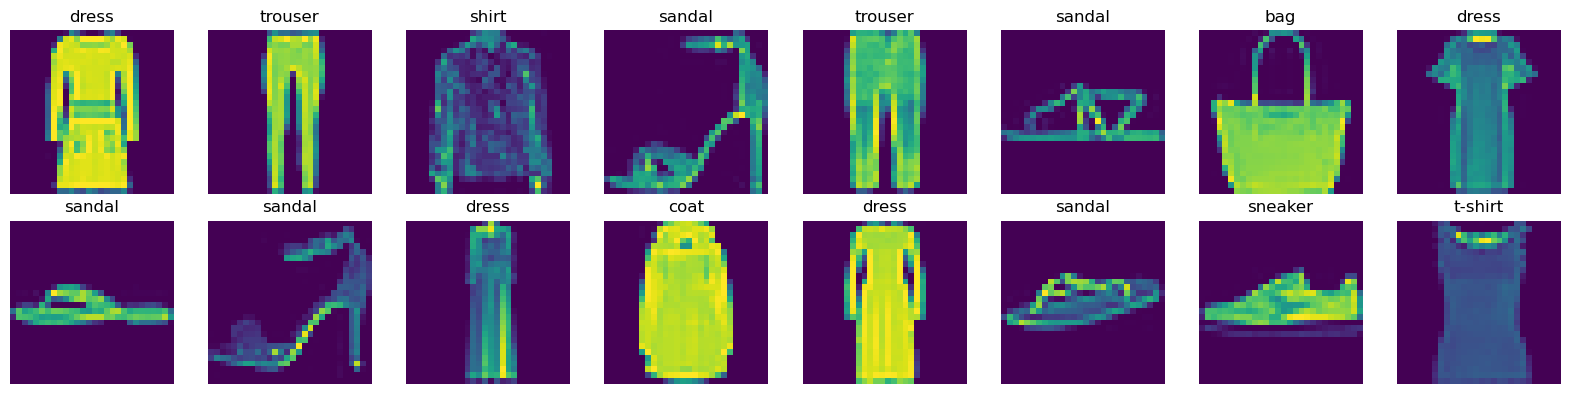

In [8]:
small_loader = data.DataLoader(mnist_train, batch_size=16, shuffle=True)
X, y = next(iter(small_loader))
show_FashionMNIST(X.reshape(16, 28, 28), 2, 8, titles=get_FashionMNIST_labels(y))

# Softmax

In [9]:
def softmax(X):
    """
    X:batch_size by num_features
    X_exp : batch_size by num_features
    partition : batch_size by 1

    return : batch_size by num_features
    """
    X_exp = torch.exp(X)
    partition = X_exp.sum(1, keepdim=True) # len(X) by 1
    return X_exp / partition # 广播机制进行归一化

In [10]:
X = torch.normal(0, 1, (2, 5)) 
# batch_size = 2;num_features = 5
X_prob = softmax(X)
X_prob, X_prob.sum(1)

(tensor([[0.2387, 0.3494, 0.1670, 0.1818, 0.0631],
         [0.0046, 0.1750, 0.6076, 0.0281, 0.1847]]),
 tensor([1.0000, 1.0000]))

In [11]:
def self_softmax_net(X):
    """
    softmax回归模型
    
    参数:
    X: 输入数据
    W: 权重矩阵(784, 10)
    b: 偏置向量(10,)
    
    X.reshape((-1,W.shape[0])) ： 256 by 784
    """
    return softmax(torch.matmul(X.reshape((-1,W.shape[0])),W) + b)

In [12]:
def cross_entropy(y_hat, y):
    """
    计算预测值与标签的交叉熵
    
    参数:
    y_hat: 预测的概率分布 (batch_size, num_classes)
    y: 真实标签 (batch_size,)
    """
    return -torch.log(y_hat[range(len(y_hat)), y])

In [13]:
def accuracy(y_hat, y):
    """计算预测准确的数量"""
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis=1) # 获取预测的类别
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

In [14]:
def evaluation_accuracy(net, data_iter):
    """计算指定数据集上模型的精度"""
    if isinstance(net, torch.nn.Module):
        net.eval() # 模型设置为评估模式
    metric = Accumulator(2) # 创建对象,执行一次  __init__ , 2 表示同时跟踪2个不同的数值
    
    for X, y in data_iter:
        if len(X.shape) == 4:
            X = X.reshape(-1,784) # 将图像展平为向量

        y_hat = net(X)
        metric.add(accuracy(y_hat, y),y.numel()) # 添加正确预测数、总数
    return metric[0] / metric[1]

In [15]:
class Accumulator:
    """在n个变量上累加"""
    def __init__(self, n):
        self.data = [0.0] * n

    def add(self, *args): # *args是可变位置参数,允许接受任意数量的参数,并存储在名为 args 的元组中
        """添加多个值到累加器"""
        self.data = [a + float(b) for a, b in zip(self.data, args)] # zip()将 elf.data 和 args 对应元素配对

    def reset(self):
        self.data = [0.0] * len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

In [16]:
def train_epoch(net, train_iter, loss, updater):
    if isinstance(net, torch.nn.Module):
        net.train()  # 设置为训练模式（启用dropout等）
    metric = Accumulator(3)  # [损失总和, 正确数, 样本总数]
    
    for X, y in train_iter:
        y_hat = net(X)
        ls = loss(y_hat, y)
        
        # isinstance(updater, torch.optim.Optimizer)检查 updater 是否是 torch.optim.Optimizer 的实例
        if isinstance(updater, torch.optim.Optimizer):
            # 使用PyTorch内置优化器
            updater.zero_grad()
            ls.sum().backward()   # 计算梯度
            updater.step()  # 更新参数
            
            metric.add(float(ls.detach().sum()),  # 损失值,使用ls.detach()创建一个没有梯度的新张量,避免梯度追踪
                    # float(ls.sum()) 试图将有梯度的张量转为浮点数, float()转换会破坏梯度计算链
                      accuracy(y_hat, y),         # 正确预测数
                      y.numel())                  # 样本数
        else:
            # 使用自定义优化器
            ls.sum().backward()  # 只有标量张量才能直接调用.backward()
            updater(X.shape[0])  # 传入batch_size给自定义优化器
            
            metric.add(float(ls.detach().sum()), 
                      accuracy(y_hat, y),   
                      y.numel()) 
            
    # 返回平均损失和准确率
    return metric[0] / metric[2], metric[1] / metric[2]

In [17]:
def sgd(params, lr, batch_size):
    """
    小批量随机梯度下降
    参数:
        params: 包含需要优化的参数的列表 [W, b]
        lr: 学习率
        batch_size: 批量大小，用于梯度归一化
    """
    with torch.no_grad():  # 不跟踪梯度计算
        for param in params:
            # 梯度除以 batch_size 进行归一化得平均梯度
            param -= lr * (param.grad / batch_size)  
            param.grad.zero_()  

In [18]:
def updater(batch_size):
    return sgd([W,b], lr, batch_size)

In [19]:
def train(net, train_iter, test_iter, loss, num_epochs, updater):
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(net, train_iter, loss, updater)
        test_acc = evaluation_accuracy(net, test_iter)
        print(f'Epoch {epoch+1}: '
              f'Train Loss {train_loss:.4f}, Acc {train_acc:.3f}; '
              f'Test Acc {test_acc:.3f}')

In [20]:
# ===== 主程序开始 =====
# 设置超参数
batch_size = 256
num_inputs = 784 # 28 by 28
num_outputs = 10 # 10 个类别
lr = 0.1
num_epochs = 8

展平每个图像，将他们视作长784的向量
数据集有10个类别，所以输出10个维度

In [21]:
# 加载训练集和测试集
*_, train_iter, test_iter = load_data_FashionMNIST(batch_size) # 只要后两个return

# 初始化模型参数
W = torch.normal(0, 0.01, size=(num_inputs, num_outputs), requires_grad=True)
b = torch.zeros(num_outputs, requires_grad=True)

# 开始训练
train(self_softmax_net, train_iter, test_iter, cross_entropy, num_epochs, updater)

训练集60000,测试集10000
数据大小torch.Size([1, 28, 28])
Epoch 1: Train Loss 0.7877, Acc 0.748; Test Acc 0.791
Epoch 2: Train Loss 0.5714, Acc 0.812; Test Acc 0.801
Epoch 3: Train Loss 0.5257, Acc 0.826; Test Acc 0.821
Epoch 4: Train Loss 0.5021, Acc 0.831; Test Acc 0.819
Epoch 5: Train Loss 0.4852, Acc 0.837; Test Acc 0.792
Epoch 6: Train Loss 0.4740, Acc 0.840; Test Acc 0.827
Epoch 7: Train Loss 0.4646, Acc 0.843; Test Acc 0.828
Epoch 8: Train Loss 0.4581, Acc 0.845; Test Acc 0.827


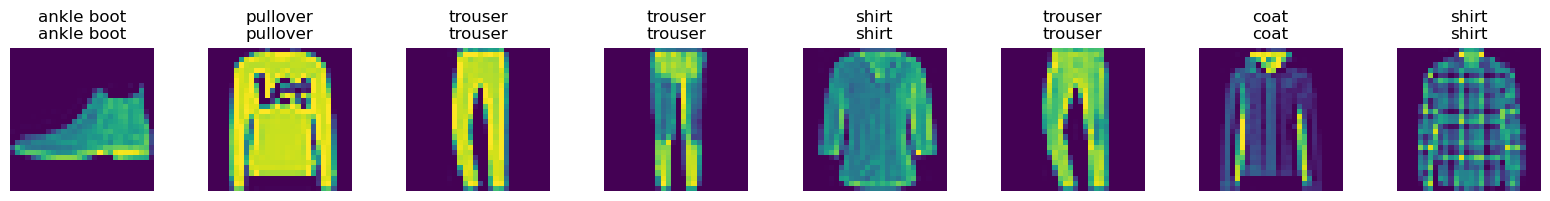

In [22]:
def predict(net, test_iter, n):
    for X, y in test_iter:
        break
    trues = get_FashionMNIST_labels(y)
    preds = get_FashionMNIST_labels(net(X).argmax(axis=1))
    titles = [true + '\n' + pred for true, pred in zip(trues, preds)]
    show_FashionMNIST(X[0:n].reshape((n, 28, 28)), 1, n, titles=titles[0:n])

predict(self_softmax_net, test_iter, 8)

# Softmax(Neutral Network)

In [23]:
import torch
from torch import nn

In [24]:
softmax_net = nn.Sequential(nn.Flatten(), nn.Linear(784, 10))
# .Flatten() Flatten Layer展平层,第0维保留,其余维度展开成向量

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

softmax_net.apply(init_weights);

In [25]:
batch_size, num_epochs, lr = 256, 8, 0.1
*_, train_iter, test_iter = load_data_FashionMNIST(batch_size)
loss = nn.CrossEntropyLoss()
trainer = torch.optim.SGD(softmax_net.parameters(), lr=lr)
train(softmax_net, train_iter, test_iter, loss, num_epochs, trainer)

训练集60000,测试集10000
数据大小torch.Size([1, 28, 28])
Epoch 1: Train Loss 0.0031, Acc 0.751; Test Acc 0.790
Epoch 2: Train Loss 0.0022, Acc 0.813; Test Acc 0.808
Epoch 3: Train Loss 0.0021, Acc 0.826; Test Acc 0.786
Epoch 4: Train Loss 0.0020, Acc 0.832; Test Acc 0.823
Epoch 5: Train Loss 0.0019, Acc 0.836; Test Acc 0.830
Epoch 6: Train Loss 0.0019, Acc 0.840; Test Acc 0.810
Epoch 7: Train Loss 0.0018, Acc 0.842; Test Acc 0.825
Epoch 8: Train Loss 0.0018, Acc 0.845; Test Acc 0.828


# 多层感知机

In [26]:
import torch
from torch import nn

In [27]:
def relu(X):
    a = torch.zeros_like(X)
    return torch.max(X,a)

In [28]:
def self_mlp_net(X):
    X = X.reshape(-1, num_inputs)
    H = relu(X @ W1 + b1)
    return (H @ W2 + b2)

In [29]:
batch_size, num_epochs, lr = 256, 8, 0.1
num_inputs, num_outputs, num_hidden = 784, 10, 256

W1 = nn.Parameter(torch.randn(num_inputs, num_hidden, requires_grad=True))
b1 = nn.Parameter(torch.zeros(num_hidden, requires_grad=True))
W2 = nn.Parameter(torch.randn(num_hidden, num_outputs, requires_grad=True))
b2 = nn.Parameter(torch.zeros(num_outputs, requires_grad=True))

params = [W1, b1, W2, b2]

In [30]:
*_, train_iter, test_iter = load_data_FashionMNIST(batch_size)
loss = nn.CrossEntropyLoss()
updater = torch.optim.SGD(params, lr=lr)
train(self_mlp_net, train_iter, test_iter, loss, num_epochs, updater)

训练集60000,测试集10000
数据大小torch.Size([1, 28, 28])
Epoch 1: Train Loss 0.0554, Acc 0.698; Test Acc 0.740
Epoch 2: Train Loss 0.0085, Acc 0.752; Test Acc 0.731
Epoch 3: Train Loss 0.0060, Acc 0.764; Test Acc 0.748
Epoch 4: Train Loss 0.0048, Acc 0.772; Test Acc 0.753
Epoch 5: Train Loss 0.0042, Acc 0.781; Test Acc 0.763
Epoch 6: Train Loss 0.0038, Acc 0.786; Test Acc 0.759
Epoch 7: Train Loss 0.0035, Acc 0.794; Test Acc 0.762
Epoch 8: Train Loss 0.0032, Acc 0.797; Test Acc 0.771


# Multilayer Perceptron(Neural Network)

In [31]:
import torch
from torch import nn

In [32]:
mlp_net = nn.Sequential(nn.Flatten(), nn.Linear(784, 256), nn.ReLU(), nn.Linear(256, 10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

In [33]:
batch_size, num_epochs, lr = 256, 8, 0.1
num_inputs, num_outputs, num_hidden = 784, 10, 256

W1 = nn.Parameter(torch.randn(num_inputs, num_hidden, requires_grad=True))
b1 = nn.Parameter(torch.zeros(num_hidden, requires_grad=True))
W2 = nn.Parameter(torch.randn(num_hidden, num_outputs, requires_grad=True))
b2 = nn.Parameter(torch.zeros(num_outputs, requires_grad=True))

params = [W1, b1, W2, b2]

*_, train_iter, test_iter = load_data_FashionMNIST(batch_size)
mlp_net.apply(init_weights)
loss = nn.CrossEntropyLoss()
updater = torch.optim.SGD(mlp_net.parameters(), lr=lr)
train(mlp_net, train_iter, test_iter, loss, num_epochs, updater)

训练集60000,测试集10000
数据大小torch.Size([1, 28, 28])
Epoch 1: Train Loss 0.0041, Acc 0.636; Test Acc 0.752
Epoch 2: Train Loss 0.0023, Acc 0.792; Test Acc 0.773
Epoch 3: Train Loss 0.0020, Acc 0.818; Test Acc 0.798
Epoch 4: Train Loss 0.0019, Acc 0.831; Test Acc 0.800
Epoch 5: Train Loss 0.0018, Acc 0.838; Test Acc 0.797
Epoch 6: Train Loss 0.0017, Acc 0.845; Test Acc 0.838
Epoch 7: Train Loss 0.0016, Acc 0.852; Test Acc 0.828
Epoch 8: Train Loss 0.0016, Acc 0.856; Test Acc 0.842
